<a href="https://colab.research.google.com/github/og-cz/CCADMACL/blob/main/Exercise3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3B

In this exercise, you will explore how the DBSCAN clustering algorithm identifies dense groups and outliers in the Pokémon statistics dataset. You will analyze the dataset, scale features, determine DBSCAN parameters, run DBSCAN, and interpret the clustering results.

In [36]:
!pip install scikit-learn

In [37]:
import kagglehub
import os
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import sklearn

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

In [2]:
# Download latest version
path = kagglehub.dataset_download("abcsds/pokemon")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


In [3]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Load the Dataset (8 pts)

Load the Pokémon dataset into a pandas DataFrame.

Show the first five rows (3 pts)

In [105]:
# put your answer here
df.head(5)

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False



How many Pokémon are in the dataset? (2 pts)


In [106]:
df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [107]:
# put your answer here
df['Name'].nunique()

800

In [146]:
print(df['Legendary'].value_counts())


Legendary
False    735
True      65
Name: count, dtype: int64



List all columns available (3 pts)

In [108]:
# put your answer here
print(df.columns.tolist())

['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']


## 2: Select Features & Clean the Data (8 pts)
`
Select the numeric features needed for clustering (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed). (3 pts)

In [109]:
# put your answer here
df_selected = df.drop(columns=['Name', 'Type 1', 'Type 2', 'Legendary'])
df_selected

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,318,45,49,49,65,65,45,1
1,2,405,60,62,63,80,80,60,1
2,3,525,80,82,83,100,100,80,1
3,3,625,80,100,123,122,120,80,1
4,4,309,39,52,43,60,50,65,1
...,...,...,...,...,...,...,...,...,...
795,719,600,50,100,150,100,150,50,6
796,719,700,50,160,110,160,110,110,6
797,720,600,80,110,60,150,130,70,6
798,720,680,80,160,60,170,130,80,6


Are there any missing values? (2 pts)

In [110]:
# put your answer here
null_data = df_selected[df_selected.isnull().any(axis=1)]

if len(null_data) == 0:
    print("Nothing is null")
else:
    for index, row in null_data.iterrows():
        print(f"Row {index} has null values:")
        print(row)

null_data


Nothing is null


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation


If missing values exist, describe how you handled them (3 pts)

In [111]:
# put your answer here
df_selected

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,318,45,49,49,65,65,45,1
1,2,405,60,62,63,80,80,60,1
2,3,525,80,82,83,100,100,80,1
3,3,625,80,100,123,122,120,80,1
4,4,309,39,52,43,60,50,65,1
...,...,...,...,...,...,...,...,...,...
795,719,600,50,100,150,100,150,50,6
796,719,700,50,160,110,160,110,110,6
797,720,600,80,110,60,150,130,70,6
798,720,680,80,160,60,170,130,80,6


# 3. Scale the Features (10 pts)

Apply StandardScaler to the selected features.

Show the transformed feature sample (e.g., first 5 rows) (10 pts)


In [112]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)
print(scaled_data[:5])

[[-1.73770518 -0.97676549 -0.95062622 -0.92490618 -0.79715364 -0.2391303
  -0.24818854 -0.80150318 -1.39963712]
 [-1.73290242 -0.25108843 -0.3628221  -0.5241302  -0.34791742  0.21955954
   0.29115635 -0.28501525 -1.39963712]
 [-1.72809965  0.74984544  0.42091674  0.09244823  0.29384863  0.83114599
   1.01028289  0.40363531 -1.39963712]
 [-1.72809965  1.58395701  0.42091674  0.64736882  1.57738071  1.50389108
   1.72940942  0.40363531 -1.39963712]
 [-1.72329689 -1.05183553 -1.18574787 -0.83241942 -0.98968346 -0.39202691
  -0.78753344 -0.11285261 -1.39963712]]


## 4. Determine a Suitable eps Value (10 pts)

Using k = 4:
Compute the distance to the 4th nearest neighbor for each Pokémon (6 pts)

In [113]:
# put your answer here
k = 4
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(scaled_data)
distances, indices = neighbors_fit.kneighbors(scaled_data)


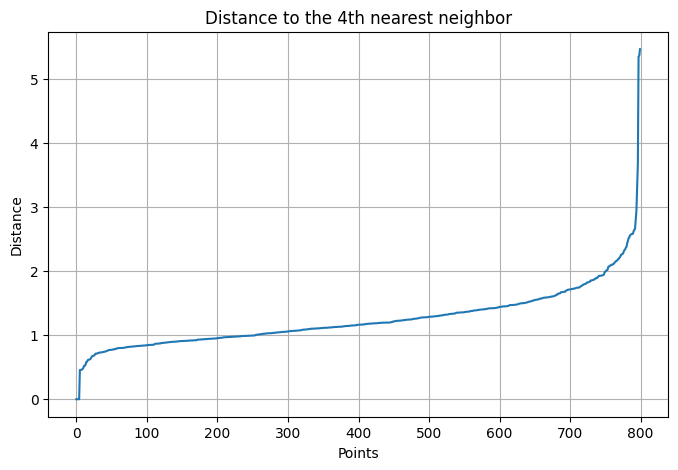

In [114]:
# Distance to the 4th nearest neighbor for each point
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title('Distance to the 4th nearest neighbor')
plt.xlabel('Points')
plt.ylabel('Distance')
plt.grid(True)
plt.show()


What is your chosen eps based on the "elbow"? (2 pts)

In [138]:
# put your answer here
eps = 0.9
print(f"Chosen eps value: {eps}")

Chosen eps value: 0.9


In [142]:
min_samples = k
min_samples_based_features = int(len(df_selected.columns.tolist()) + 1)
print(f'min samples is {min_samples}')
print(f'min samples based on number of features is {min_samples_based_features}')



min samples is 4
min samples based on number of features is 10


One-sentence explanation of your reasoning (2 pts)

# put your answer here

**i choosed 0.4 because its the value in the plot where the elbow`s curves beforehand start bending**

## 5. Run DBSCAN (10 points)

Run DBSCAN using your chosen eps and min_samples


How many clusters did DBSCAN find? (4 pts)

In [143]:
# put your answer here
dbscan_min_samples = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_based_features = DBSCAN(eps=eps, min_samples=min_samples_based_features)

labels_min_samples = dbscan_min_samples.fit_predict(scaled_data)
labels_based_features = dbscan_based_features.fit_predict(scaled_data)

df_selected_min_sample = df_selected.copy()
df_selected_based_features = df_selected.copy()

df_selected_min_sample['Cluster'] = labels_min_samples
df_selected_based_features['Cluster'] = labels_based_features

In [144]:
print(df_selected_min_sample['Cluster'].value_counts())
df_selected_min_sample.head(15)

Cluster
-1     566
 5      96
 0      27
 9      13
 17     12
 2       9
 8       9
 4       7
 16      5
 1       5
 12      5
 20      5
 13      5
 6       5
 3       4
 15      4
 7       4
 11      4
 18      4
 14      4
 19      4
 10      3
Name: count, dtype: int64


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Cluster
0,1,318,45,49,49,65,65,45,1,0
1,2,405,60,62,63,80,80,60,1,1
2,3,525,80,82,83,100,100,80,1,4
3,3,625,80,100,123,122,120,80,1,-1
4,4,309,39,52,43,60,50,65,1,0
5,5,405,58,64,58,80,65,80,1,1
6,6,534,78,84,78,109,85,100,1,4
7,6,634,78,130,111,130,85,100,1,-1
8,6,634,78,104,78,159,115,100,1,-1
9,7,314,44,48,65,50,64,43,1,0


How many Pokémon were labeled as noise? (4 pts)

In [ ]:
# put your answer here
there are 566 pokemon that were labeled as noise because of the cluster "-1"

Show the unique labels output by DBSCAN (2 pts)

In [147]:
# put your answer here
print(df_selected_min_sample['Cluster'].unique())


[ 0  1  4 -1  2  3  5  6  8  7 12  9 10 11 13 14 15 16 17 18 19 20]


## 6. Attach Cluster Labels to the Original Dataset (7 points)

Add the cluster labels back to the original DataFrame (3 pts)

In [ ]:
# put your answer here

Show the first 10 rows including the cluster label (4 pts)

In [ ]:
# put your answer here

## 7. Explore the Clusters (12 points)

For each cluster:


How many Pokémon does it contain? (4 pts)

In [ ]:
# put your answer here

What are the average Attack, Defense, and Speed? (4 pts)


In [ ]:
# put your answer here

Compare the clusters: What differences do you notice? (4 pts)

In [ ]:
# put your answer here

## 8. Identify Outliers (10 points)

List all Pokémon labeled as noise (cluster = -1) (4 pts)

In [ ]:
# put your answer here

Are many of them legendary? (3 pts)

In [ ]:
# put your answer here

Explain why DBSCAN might classify them as outliers (3 pts)

In [ ]:
# put your answer here

## 9. Interpret the Clustering Results (25 points)
Write a short interpretation (4–6 sentences).
Discuss:


What types of Pokémon grouped together (5 pts)

In [ ]:
# put your answer here

Whether the clusters make intuitive sense (10 pts)

In [ ]:
# put your answer here


What the noise points reveal about DBSCAN (5 pts)


In [ ]:
# put your answer here

What stat patterns you discovered (5 pts)

In [ ]:
# put your answer here

# Task
Based on the generated elbow plot, identify the optimal 'eps' value by locating the point of maximum curvature where the distance curve sharply changes slope. Then, provide a one-sentence explanation for your choice, justifying why this 'eps' value is suitable for DBSCAN based on the visual interpretation of the plot. Run the DBSCAN algorithm using the determined 'eps' value and 'min_samples' (k=4). Calculate and report the number of clusters found and the number of Pokémon identified as noise. Integrate the DBSCAN cluster labels into the original DataFrame and display the first 10 rows, including the new cluster label column. For each identified cluster, determine the number of Pokémon it contains and calculate the average 'Attack', 'Defense', and 'Speed' statistics, comparing the clusters based on these averages. List all Pokémon labeled as noise (cluster = -1), investigate how many are legendary, and explain why DBSCAN might classify them as outliers. Finally, write a concise interpretation (4-6 sentences) of the clustering results, discussing grouped Pokémon types, the intuitive sense of the clusters, what noise points reveal about DBSCAN, and any significant statistical patterns discovered.

# Task
Identify the optimal 'eps' value from the generated elbow plot by locating the point of maximum curvature, explain the reasoning for this choice, then run the DBSCAN algorithm with the chosen 'eps' and `min_samples=4`, calculate the number of clusters and noise points, integrate the cluster labels into the original DataFrame, and display the first 10 rows with the new labels. Afterwards, for each cluster, determine the number of Pokémon and calculate the average 'Attack', 'Defense', and 'Speed' statistics, comparing the clusters based on these averages. Finally, list all noise Pokémon (cluster = -1), identify how many are legendary, explain why DBSCAN might classify them as outliers, and provide a concise interpretation (4-6 sentences) of the clustering results, discussing grouped Pokémon types, the intuitive sense of the clusters, what noise points reveal about DBSCAN, and any significant statistical patterns discovered.

## Identify and Explain Eps

### Subtask:
Based on the generated elbow plot, identify the optimal 'eps' value by locating the point of maximum curvature where the distance curve sharply changes slope. Then, provide a one-sentence explanation for your choice, justifying why this 'eps' value is suitable for DBSCAN based on the visual interpretation of the plot.


**Reasoning**:
Based on the visual inspection of the elbow plot, I've identified the point where the curve sharply changes slope. I will now input this value and provide a brief explanation for my choice.

